In [20]:
from typing import TypedDict

from git_study.graphs.commit_analysis_subgraph import commit_analysis_subgraph
from git_study.graphs.general_grade_graph import general_grade_graph
from git_study.graphs.inline_grade_graph import inline_grade_graph
from git_study.graphs.inline_quiz_graph import inline_quiz_graph
from git_study.graphs.quiz_graph import quiz_graph
from git_study.graphs.read_graph import read_graph
from git_study.tools.code_context import build_get_neighbor_code_context_tool
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode


def build_tool_demo_graph():
    class ToolDemoState(TypedDict, total=False):
        prompt: str

    tool = build_get_neighbor_code_context_tool(
        {"src/example.py": "def run():\n    value = compute()\n    return value\n"}
    )

    def tool_demo_entry(state: ToolDemoState) -> ToolDemoState:
        return state

    tool_demo_builder = StateGraph(ToolDemoState)
    tool_demo_builder.add_node("assistant", tool_demo_entry)
    tool_demo_builder.add_node("get_neighbor_code_context", ToolNode([tool]))
    tool_demo_builder.add_edge(START, "assistant")
    tool_demo_builder.add_conditional_edges(
        "assistant",
        lambda state: "tool",
        {"tool": "get_neighbor_code_context"},
    )
    tool_demo_builder.add_edge("get_neighbor_code_context", "assistant")
    return tool_demo_builder.compile(name="neighbor_code_context_tool_demo")


tool_demo_graph = build_tool_demo_graph()

graphs = {
    "commit_analysis_subgraph": commit_analysis_subgraph,
    "quiz_graph": quiz_graph,
    "read_graph": read_graph,
    "inline_quiz_graph": inline_quiz_graph,
    "inline_grade_graph": inline_grade_graph,
    "general_grade_graph": general_grade_graph,
    "tool_demo_graph": tool_demo_graph,
}

graphs

{'commit_analysis_subgraph': <langgraph.graph.state.CompiledStateGraph at 0x12fc84b00>,
 'quiz_graph': <langgraph.graph.state.CompiledStateGraph at 0x12fc85220>,
 'read_graph': <langgraph.graph.state.CompiledStateGraph at 0x12fc85480>,
 'inline_quiz_graph': <langgraph.graph.state.CompiledStateGraph at 0x12fc850f0>,
 'inline_grade_graph': <langgraph.graph.state.CompiledStateGraph at 0x12fc84d60>,
 'general_grade_graph': <langgraph.graph.state.CompiledStateGraph at 0x12fc84c30>,
 'tool_demo_graph': <langgraph.graph.state.CompiledStateGraph at 0x13821c510>}

In [21]:
for name, graph in graphs.items():
    graph.get_graph()

## commit_analysis_subgraph

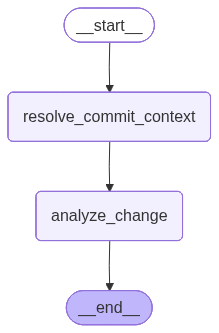

## quiz_graph

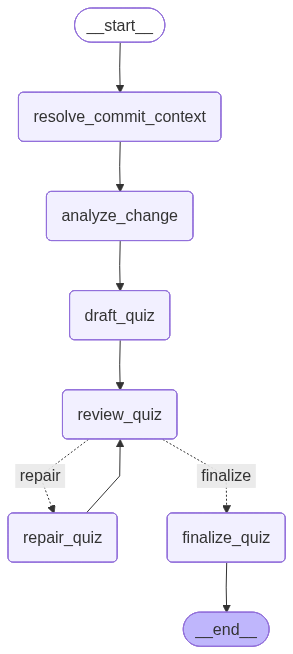

## read_graph

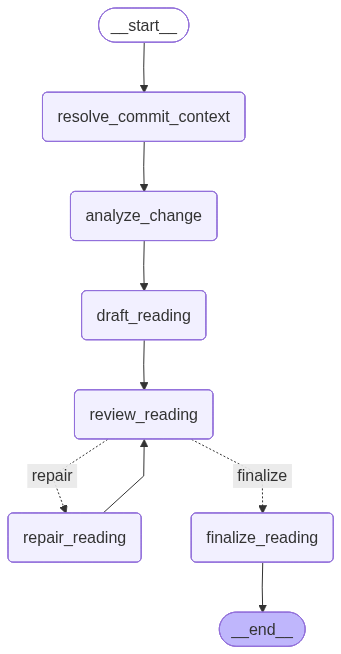

## inline_quiz_graph

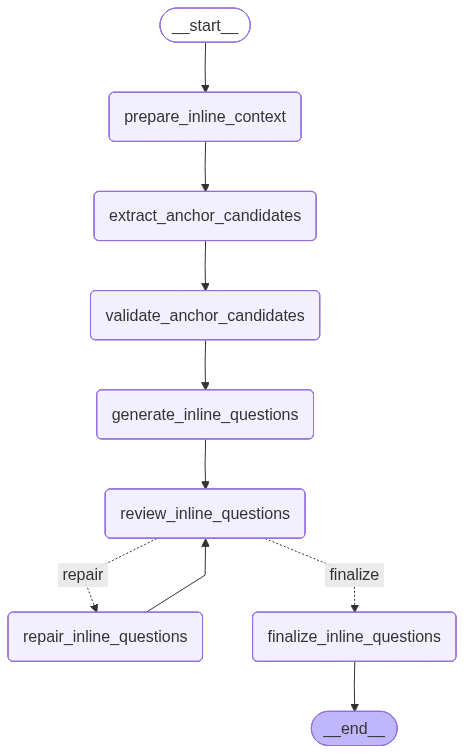

## inline_grade_graph

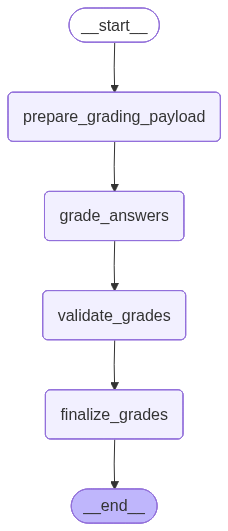

## general_grade_graph

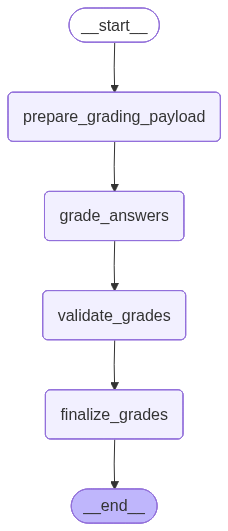

## tool_demo_graph

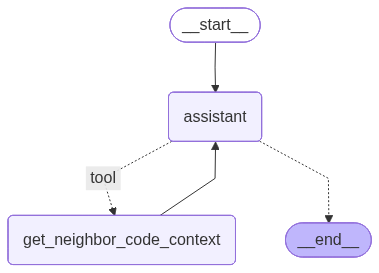

In [22]:
from IPython.display import Image, Markdown, display


def display_graph(name, graph):
    display(Markdown(f"## {name}"))
    compiled = graph.get_graph()
    try:
        png = compiled.draw_mermaid_png()
    except Exception as exc:
        display(Markdown("PNG 렌더링에 실패해서 Mermaid 텍스트를 대신 표시합니다."))
        display(Markdown(f"```mermaid\n{compiled.draw_mermaid()}\n```"))
        print(type(exc).__name__, exc)
        return
    display(Image(png))


for name, graph in graphs.items():
    display_graph(name, graph)

In [23]:
quiz_graph.get_graph().draw_mermaid()

'---\nconfig:\n  flowchart:\n    curve: linear\n---\ngraph TD;\n\t__start__([<p>__start__</p>]):::first\n\tresolve_commit_context(resolve_commit_context)\n\tanalyze_change(analyze_change)\n\tdraft_quiz(draft_quiz)\n\treview_quiz(review_quiz)\n\trepair_quiz(repair_quiz)\n\tfinalize_quiz(finalize_quiz)\n\t__end__([<p>__end__</p>]):::last\n\t__start__ --> resolve_commit_context;\n\tanalyze_change --> draft_quiz;\n\tdraft_quiz --> review_quiz;\n\trepair_quiz --> review_quiz;\n\tresolve_commit_context --> analyze_change;\n\treview_quiz -. &nbsp;finalize&nbsp; .-> finalize_quiz;\n\treview_quiz -. &nbsp;repair&nbsp; .-> repair_quiz;\n\tfinalize_quiz --> __end__;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n'